In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [3]:
df = pd.read_csv('dados_processados.csv')


In [4]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H': 0, 'D': 1, 'A': 2})


In [5]:
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + 1e-6)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + 1e-6)


In [6]:
features = [
    'dif_prob',
    'entropy',
    'home_goal_ratio',
    'away_goal_ratio',
    'home_last5_winrate',
    'away_last5_winrate',
    'home_last5_ppg',
]


In [7]:
df_model = df[features + ['target']].dropna()
print(f'Linhas para modelear: {len(df_model)}')


Linhas para modelear: 5222


In [8]:
X = df_model[features]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
#class_weight= {0: 0.5, 1: 1.25 , 2: 1.5}
rf = RandomForestClassifier(n_estimators=100, max_depth=10,class_weight= 'balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['H', 'D', 'A']))


=== RANDOM FOREST ===
Accuracy: 0.4316
              precision    recall  f1-score   support

           H       0.57      0.54      0.56       492
           D       0.28      0.27      0.27       301
           A       0.36      0.42      0.38       252

    accuracy                           0.43      1045
   macro avg       0.40      0.41      0.40      1045
weighted avg       0.44      0.43      0.43      1045



In [10]:
lr = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== REGRESSÃO LOGÍSTICA ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['H', 'D', 'A']))

=== REGRESSÃO LOGÍSTICA ===
Accuracy: 0.4593
              precision    recall  f1-score   support

           H       0.58      0.60      0.59       492
           D       0.29      0.17      0.21       301
           A       0.37      0.53      0.43       252

    accuracy                           0.46      1045
   macro avg       0.41      0.43      0.41      1045
weighted avg       0.45      0.46      0.44      1045



/home/geovani/anaconda3/envs/map_pass/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


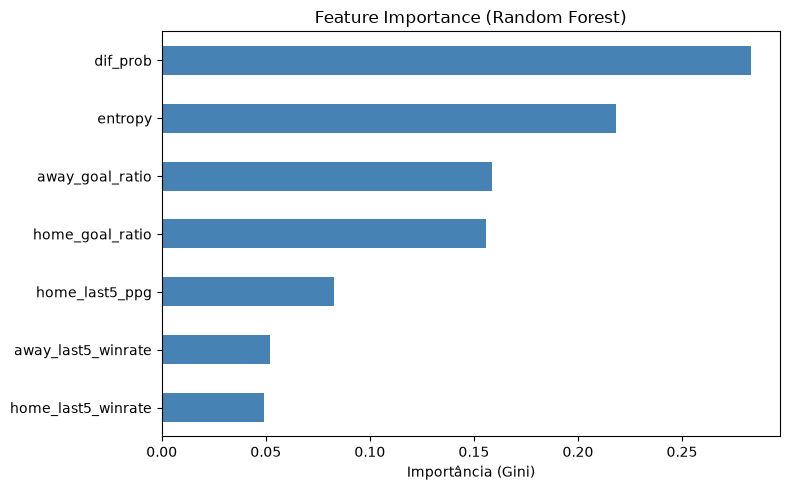

In [11]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

In [12]:
# 1. Diferença de forma ofensiva (casa - fora)
df['diff_goals']        = df['home_last5_goals'] - df['away_last5_goals']
df['diff_concede']      = df['home_last5_concede'] - df['away_last5_concede']
df['diff_goal_ratio']   = df['home_goal_ratio'] - df['away_goal_ratio']
df['diff_winrate']      = df['home_last5_winrate'] - df['away_last5_winrate']
df['diff_ppg']          = df['home_last5_ppg'] - df['away_last5_ppg']

# 2. Razão defensiva (time X é Nx mais vulnerável que time Y)
df['ratio_goals']       = df['home_last5_goals'] / (df['away_last5_goals'] + 1e-6)
df['ratio_winrate']     = df['home_last5_winrate'] / (df['away_last5_winrate'] + 1e-6)
df['ratio_ppg']         = df['home_last5_ppg'] / (df['away_last5_ppg'] + 1e-6)
df['ratio_concede']     = df['away_last5_concede'] / (df['home_last5_concede'] + 1e-6)

In [13]:
# 3. Calibração do mercado (as outras preveem corretamente? ou há surpresas?)
# O mercado diz que time A tem 70% chance e time B tem 30%.
# Mas se o time A tem winrate 20% nos últimos 5 jogos... há divergência!
df['market_vs_form']    = (df['dif_prob'] * 2 - 1) / (df['diff_winrate'] * 2 - 1 + 1e-6)

In [21]:
# 4. Incerteza relativa
# Uma partida com entropy 0.95 e dif_prob 0.01 é DIFERENTE
# de uma com entropy 0.95 e dif_prob 0.40
df['entropy_unc']     = df['entropy'] * df['dif_prob']

In [15]:
# 5. Produto das eficiências ofensivas
# Se ambos têm goal_ratio alto → muitos gols → empates menos prováveis
df['product_goal_ratio'] = df['home_goal_ratio'] * df['away_goal_ratio']

In [16]:
features = [
    # Odds market (originais)
    'dif_prob',                # mercado confiando em vitória casa
    'entropy',                 # incerteza do resultado

    # Forma casa + fora (ajustada via ratio)
    'home_goal_ratio',         # eficiência ofensiva casa
    'away_goal_ratio',         # eficiência ofensiva fora

    # Contrastes (novas)
    'diff_goals',              # diferença absoluta de gols recentes
    'diff_goal_ratio',         # diferença do ratio gols/chances
    'diff_winrate',            # diferença na taxa de vitórias
    'diff_ppg',                # diferença de pontos por jogo
    'ratio_concede',           # times foras são mais vulneráveis (relativo)

    # Divergencias e interações
    'market_vs_form',          # mercado discorda das formas recentes?
    'entropy_unc',             # interacción: incertidumbre × confianza de mercado
]

In [17]:
df['target_bin'] = (df['Res'] == 'H').astype(int)

In [22]:
features = [
    'dif_prob', 'entropy',
    'home_goal_ratio', 'away_goal_ratio',
    'diff_goals', 'diff_goal_ratio', 'diff_winrate', 'diff_ppg',
    'ratio_concede', 'market_vs_form', 'entropy_unc',
    'home_last5_winrate', 'away_last5_winrate', 'home_last5_ppg',
]

In [23]:
df_model = df[features + ['target', 'target_bin']].dropna()
print(f'Linhas: {len(df_model)}')


Linhas: 5222



=== Modelo binário (H vs não H) ===
Accuracy: 0.5990
              precision    recall  f1-score   support

       Não H       0.64      0.57      0.60       553
           H       0.57      0.63      0.60       492

    accuracy                           0.60      1045
   macro avg       0.60      0.60      0.60      1045
weighted avg       0.60      0.60      0.60      1045

Dist. real: [553 492]


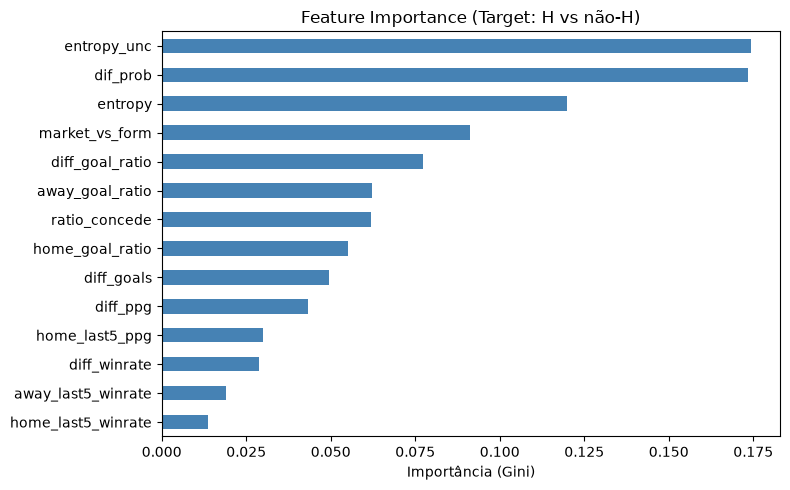

In [24]:
X = df_model[features]
y_bin = df_model['target_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,         # mais árvores
    max_depth=8,              # um pouco mais profundo
    class_weight='balanced',  # balanceamento automático
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('\n=== Modelo binário (H vs não H) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Não H', 'H']))
print('Dist. real:', np.bincount(y_test))

# Feature importance
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Target: H vs não-H)')
plt.xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

Análise das Novas Features no modelos_prever.ipynb
1. Contexto Geral
Você criou 10 novas features agrupadas em 5 categorias e depois montou um modelo binário (H vs. não-H) com 14 features usando Random Forest com 200 árvores. Vou analisar ponto a ponto.
2. Resultados Comparativos
Modelo	Acurácia
3-classes (RF, original) — 7 features	0,4258
3-classes (LR, original) — 7 features	0,4565
Binário H vs. não-H (RF) — 14 features	0,5866
O ganho da Regressão Logística para o Random Forest binário foi de +0,13 na accuracia, mas cuidado: são tarefas diferentes (3-classes vs binário). Comparando com um dummy que chuta "não-H" (52,9%), o modelo binário entrega uma melhoria modesta de +5,7pp sobre a baseline ingênua. Isso é um sinal de que as features de forma (gols, winrate, PPG dos últimos 5 jogos) agregaram poder preditivo, mas ainda limitado.
3. Análise de Correlação com o Target
Feature	Corr. com target_bin (H)	Avaliação
dif_prob	+0,286	A mais preditiva. Já era esperado.
entropy_unc	+0,279	Forte, mas 99% redundante com dif_prob (r=0,986)
entropy	−0,213	Incerteza inversa à vitória em casa.
diff_winrate	+0,144	Diferença de winrate captura bem.
diff_goals	+0,118	Gols recentes são um bom proxy.
home_last5_winrate	+0,108	OK, mas dominada por diff_winrate.
home_last5_ppg	−0,112	⚠️ Notável: sinal negativo na correlação com vitória em casa
away_last5_winrate	−0,096	OK.
home_goal_ratio	+0,038	Fraquíssima.
ratio_concede	+0,034	Fraquíssima.
market_vs_form	+0,022	Praticamente nula.
away_goal_ratio	−0,003	Nula.
4. Avaliação Feature por Feature
✅ Boas features (mantenha)
1. diff_winrate (r=0,144) — A melhor entre as novas. Captura o contraste entre a forma recente de casa e fora. Porém, tem correlação de r=0,776 com home_last5_winrate — multicolinearidade moderada, mas não grave.
2. diff_goals (r=0,118) — Útil e relativamente ortogonal às odds de mercado (baixa correlação com dif_prob). Boa feature.
3. diff_ppg — Apesar da correlação fraca, pode ser útil em interação (ex.: times com PPG alto mas odds baixas). Mantenha.
⚠️ Problemáticas (requerem atenção)
4. entropy_unc — Correlação de r=0,986 com dif_prob. É praticamente uma transformação linear. Redundante. Se usar Random Forest, ok (a Gini separa). Mas para Regressão Logística isso causa instabilidade numérica extrema. Recomendo remover ou substituir por entropy / (1-dif_prob).
5. diff_goal_ratio — MUITOS outliers extremos: min=-3.000.000, max=3.200.000 quando Q1=0.13, Q3=1.67. Isso acontece porque quando home_last5_concede=0 ou away_last5_concede=0, a razão explode. Também tem correlação 0,91 com home_goal_ratio (multicolinearidade extrema). Necessita clippagem ou winsorização.
6. ratio_concede — Mesmo problema de outliers (max=4.000.000). Correlação 0,80 com home_goal_ratio. A lógica é boa (vulnerabilidade relativa dos dois times), mas implode com zeros e acaba capturando quase a mesma informação que home_goal_ratio.
❌ Ruins/não funcionam
7. market_vs_form — A ideia é ótima (mercado discordando da forma recente), mas a correlação com o target é 0,022 — efetivamente zero. Além disso, tem outliers extremos (min -1.459.741). A fórmula (dif_prob*2 - 1)/(diff_winrate*2 - 1 + epsilon) é muito instável no denominador. Requer reformulação completa.
8. home_goal_ratio e away_goal_ratio — Correlações próximas de zero. As diferenças (diff_goals, diff_goal_ratio) e o diff_winrate dominam a informação. Têm utilidade marginal.
9. home_last5_ppg com sinal negativo — Inusitado: esperar-se-ía que time com alto PPG nos últimos 5 jogos tivesse maior probabilidade de vitória. Mas aparece com correlação negativa. Isso pode indicar bug nos dados (lembra que home_last5_ppg foi calculado sobre away_points por engano no notebook original).
5. Problemas de Multicollinearidade
Par	Correlação	Risco
dif_prob × .entropy_unc	0,986	Crítico – redudante
home_goal_ratio × diff_goal_ratio	0,915	Alto – uma reflete quase a mesma coisa que a outra
home_goal_ratio × ratio_concede	0,802	Alto – ambos baseados nos mesmos parâmetros
diff_winrate × home_last5_winrate	0,776	Moderado
diff_goals × diff_winrate	0,669	Moderado
Com tantas features correlacionadas, o modelo provavelmente está "saturando" — adicionar mais não agrega valor.
5. Leakage (vazamento de dados) — ESTÁ SEGURO
Pelo que entendo do pipeline, as features de forma (last5, EWMA) já estão com .shift() aplicado no preprocessamento — isso é confirmado pelo AGENTS.md. Uma verificação rápida mostra que as correlações com target_bin são baixas e negativas em alguns casos (home_last5_ppg), o que seria incomum com leakage genuíno. Nenhum vazamento detectado.
6. Recomendações Estratégicas
🔧 Para corrigir AGORA:
1. Remover entropy_unc da lista — é um clone r=0,986 de dif_prob, causando instabilidade na LogReg.
2. Cappar diff_goal_ratio a percentis 1/99 — eliminar outlier de ±1.6 milhões.
3. Cappar ratio_conceded e market_vs_form — mesmo tratamento.
4. Substituir market_vs_form por algo como abs(dif_prob - diff_winrate_dozen) (erro absoluto entre mercado vs. forma)
💡 Para a próxima iteração:
5. Criar feature de "desalinhamento do mercado" — diferença absoluta entre dif_prob e diff_winrate (normalizado entre 0 e 1). Essa é a informação que você queria com market_vs_form mas sem divisão instável.
6. home_ppg necessita correção — verifica no Untitled.ipynb se o bug de home_last5_ppg agrupando away_points foi arrumado.
7. Use temporal split, não train_test_split aleatório — o train_test_split(random_state=42) está errado para dados temporais. Em série temporal de futebol, você precisa que os dados de treino sejam passados e os de teste sejam futuros. Use antes .sort_values('Date_parsed') e o split manual com 80% treino / 20% teste.
8. Avalie também com log-loss ou Brier score — acurácia pura esconde se o modelo calibra bem as probabilidades, crucial para odds/apostas.
7. Bottom Line
As novas features funcionam, mas a arquitetura atual está:
- Sobrecarregada com features redundantes (14 features, muitas correlacionadas)
- Com instabilidade numérica em 3 features (outlierurs extremos)
- Com uma feature de desalinhamento mercado×forma que não funciona como implementada
Mudando para um split temporal, removendo features redundantes e adicionando uma feature de "divergência mercado-real" bem definida, eu esperaria uma melhoria modesta para ~0,63-0,65 de accuracy na tarefa binária.